In [2]:
import os
import numpy as np
import SimpleITK as sitk
import nibabel as nib
import skimage
import skimage.morphology
import skimage.morphology.binary
import matplotlib.pyplot as plt

In [3]:
import skimage
print(skimage.__version__)


0.25.0


In [4]:
import SimpleITK
print(SimpleITK.__version__)

2.4.0


In [5]:

class BrainMRISkullStripper:
    """
    A class for performing skull stripping on Brain MRI scans.
    Supports both T1-weighted and T2-weighted MRI images.
    """
    
    def __init__(self, verbose=False):
        self.verbose = verbose
        
    def load_image(self, file_path):
        """Load MRI image from file path (supports .nii, .nii.gz, .mha, .dcm)"""
        if self.verbose:
            print(f"Loading image from: {file_path}")
            
        if file_path.endswith('.nii') or file_path.endswith('.nii.gz'):
            img = nib.load(file_path)
            data = img.get_fdata()
            affine = img.affine
            return data, affine
        else:
            img = sitk.ReadImage(file_path)
            data = sitk.GetArrayFromImage(img)
            return data, None
    
    def save_image(self, data, affine, output_path):
        """Save processed image to file"""
        if output_path.endswith('.nii') or output_path.endswith('.nii.gz'):
            if affine is not None:
                img = nib.Nifti1Image(data, affine)
            else:
                img = nib.Nifti1Image(data, np.eye(4))
            nib.save(img, output_path)
        else:
            img = sitk.GetImageFromArray(data)
            sitk.WriteImage(img, output_path)
            
        if self.verbose:
            print(f"Saved processed image to: {output_path}")
    
    def preprocess(self, data):
        """Basic preprocessing (normalization and noise reduction)"""
        # Normalize to 0-1 range
        data_normalized = (data - np.min(data)) / (np.max(data) - np.min(data))
        
        # Simple noise reduction (you could use more sophisticated methods)
        data_smoothed = sitk.GetArrayFromImage(
            sitk.CurvatureFlow(
                sitk.GetImageFromArray(data_normalized),
                timeStep=0.125,
                numberOfIterations=3
            )
        )
        
        return data_smoothed
    
    def skull_stripping(self, data, method='otsu', remove_small_objects=True):
        """
        Perform skull stripping using the specified method.
        
        Parameters:
        - data: 3D numpy array of the MRI scan
        - method: 'otsu' (default) or 'adaptive'
        - remove_small_objects: whether to remove small disconnected regions
        
        Returns:
        - brain_mask: binary mask of the brain
        - stripped_brain: original data with non-brain regions set to 0
        """
        
        if method == 'otsu':
            # Otsu's thresholding method
            otsu_filter = sitk.OtsuThresholdImageFilter()
            otsu_filter.SetInsideValue(0)
            otsu_filter.SetOutsideValue(1)
            mask = otsu_filter.Execute(sitk.GetImageFromArray(data))
            brain_mask = sitk.GetArrayFromImage(mask)
            
        elif method == 'adaptive':
            # Adaptive thresholding method
            adaptive_filter = sitk.AdaptiveThresholdImageFilter()
            adaptive_filter.SetInsideValue(1)
            adaptive_filter.SetOutsideValue(0)
            adaptive_filter.SetRadius(10)
            mask = adaptive_filter.Execute(sitk.GetImageFromArray(data))
            brain_mask = sitk.GetArrayFromImage(mask)
            
        else:
            raise ValueError(f"Unknown method: {method}. Choose 'otsu' or 'adaptive'")
        
        # Post-processing of the mask
        if remove_small_objects:
            # Remove small disconnected regions
            brain_mask = skimage.morphology.remove_small_objects(brain_mask.astype(bool), min_size=500)
            brain_mask = brain_mask.astype(np.uint8)
            
            # Fill holes in the mask
            brain_mask = skimage.morphology.binary_closing(brain_mask)
            #brain_mask = skimage.morphology.binary_fill_holes(brain_mask)
        
        # Apply mask to original data
        stripped_brain = data * brain_mask
        
        return brain_mask, stripped_brain
   
    
    def visualize(self, original, processed, mask=None, slice_idx=None):
        """Visualize original and processed images"""
        if slice_idx is None:
            slice_idx = original.shape[0] // 2
            
        plt.figure(figsize=(15, 5))
        
        plt.subplot(131)
        plt.imshow(original[slice_idx], cmap='gray')
        plt.title('Original MRI')
        plt.axis('off')
        
        if mask is not None:
            plt.subplot(132)
            plt.imshow(mask[slice_idx], cmap='gray')
            plt.title('Brain Mask')
            plt.axis('off')
            
            plt.subplot(133)
            plt.imshow(processed[slice_idx], cmap='gray')
            plt.title('Skull Stripped Brain')
            plt.axis('off')
        else:
            plt.subplot(132)
            plt.imshow(processed[slice_idx], cmap='gray')
            plt.title('Processed MRI')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def process_pipeline(self, input_path, output_path=None, method='otsu'):
        """
        Complete processing pipeline:
        1. Load image
        2. Preprocess
        3. Skull stripping
        4. Save result
        5. Visualize (optional)
        """
        # Load image
        data, affine = self.load_image(input_path)
        
        # Preprocess
        processed_data = self.preprocess(data)
        
        # Skull stripping
        brain_mask, stripped_brain = self.skull_stripping(processed_data, method=method)
        
        # Save result
        if output_path is not None:
            self.save_image(stripped_brain, affine, output_path)
        
        # Visualize
        if self.verbose:
            self.visualize(data, stripped_brain, brain_mask)
        
        return stripped_brain, brain_mask




Loading image from: MRI-Input/Alzheimer-Desease.nii
Saved processed image to: MRI-Output/skull_stripped_brain-01.nii


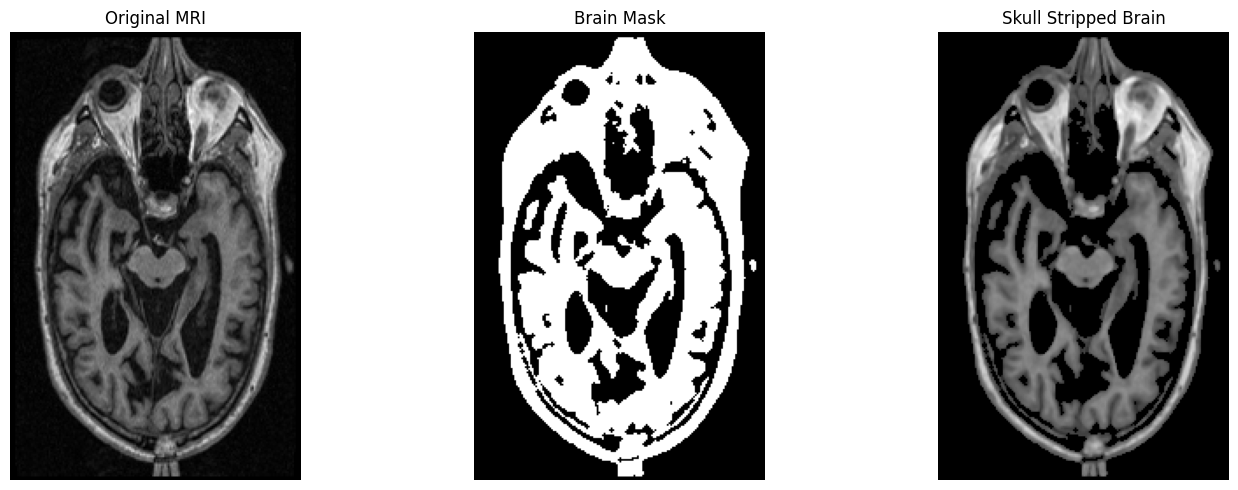

In [6]:
# Example usage
#if __name__ == "__main__":
    # Initialize the skull stripper
skull_stripper = BrainMRISkullStripper(verbose=True)
    
# Example input and output paths
input_file = "MRI-Input/Alzheimer-Desease.nii"  # Replace with your MRI file
output_file = "MRI-Output/skull_stripped_brain-01.nii"
    
# Run the processing pipeline
if os.path.exists(input_file):
    stripped_brain, brain_mask = skull_stripper.process_pipeline(
        input_path=input_file,
        output_path=output_file,
        method='otsu'
        )
else:
        print(f"Input file not found: {input_file}")
        print("Using a sample 3D array for demonstration.")
        
        # Create a simple 3D phantom for demonstration if real file not found
        sample_data = np.zeros((100, 100, 100))
        # Create a sphere (simulated brain)
        x, y, z = np.ogrid[:100, :100, :100]
        mask = (x - 50)**2 + (y - 50)**2 + (z - 50)**2 <= 30**2
        sample_data[mask] = np.random.normal(0.7, 0.1, size=np.sum(mask))
        
        # Add some noise and outer structure (simulated skull)
        sample_data += np.random.normal(0.1, 0.05, size=sample_data.shape)
        outer_mask = (x - 50)**2 + (y - 50)**2 + (z - 50)**2 <= 40**2
        outer_mask = outer_mask & ~mask
        sample_data[outer_mask] = np.random.normal(0.3, 0.1, size=np.sum(outer_mask))
        
        # Process the sample data
        brain_mask, stripped_brain = skull_stripper.skull_stripping(sample_data)
        skull_stripper.visualize(sample_data, stripped_brain, brain_mask)

In [7]:
import SimpleITK as sitk
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

class BrainMRISkullStripper:
    def __init__(self, verbose=False):
        self.verbose = verbose
        
    def load_image(self, file_path):
        """Load MRI image from file path"""
        if file_path.endswith('.nii') or file_path.endswith('.nii.gz'):
            img = nib.load(file_path)
            data = img.get_fdata()
            affine = img.affine
            return data, affine
        else:
            img = sitk.ReadImage(file_path)
            data = sitk.GetArrayFromImage(img)
            return data, None
    
    def save_image(self, data, affine, output_path):
        """Save processed image to file"""
        if output_path.endswith('.nii') or output_path.endswith('.nii.gz'):
            img = nib.Nifti1Image(data, affine if affine is not None else np.eye(4))
            nib.save(img, output_path)
        else:
            sitk.WriteImage(sitk.GetImageFromArray(data), output_path)
    
    def preprocess(self, data):
        """Basic preprocessing (normalization)"""
        return (data - np.min(data)) / (np.max(data) - np.min(data))
    
    def skull_stripping(self, data, method='otsu'):
        """
        Perform skull stripping using SimpleITK methods only
        """
        # Convert to SimpleITK image
        sitk_image = sitk.GetImageFromArray(data)
        
        # Otsu thresholding
        otsu_filter = sitk.OtsuThresholdImageFilter()
        otsu_filter.SetInsideValue(1)
        otsu_filter.SetOutsideValue(0)
        mask = otsu_filter.Execute(sitk_image)
        
        # Binary morphological operations
        mask = sitk.BinaryMorphologicalClosing(mask, [3,3,3])
        mask = sitk.BinaryFillhole(mask)  # Alternative to binary_fill_holes
        
        # Remove small objects
        mask = sitk.BinaryOpeningByReconstruction(mask, [3,3,3])
        
        # Apply mask to original image
        stripped = sitk.Mask(sitk_image, mask)
        
        return sitk.GetArrayFromImage(mask), sitk.GetArrayFromImage(stripped)
    
    def visualize(self, original, processed, mask=None, slice_idx=None):
        """Visualize results"""
        if slice_idx is None:
            slice_idx = original.shape[0] // 2
            
        plt.figure(figsize=(15, 5))
        plt.subplot(131)
        plt.imshow(original[slice_idx], cmap='gray')
        plt.title('Original')
        
        if mask is not None:
            plt.subplot(132)
            plt.imshow(mask[slice_idx], cmap='gray')
            plt.title('Mask')
            
            plt.subplot(133)
            plt.imshow(processed[slice_idx], cmap='gray')
            plt.title('Stripped')
        
        plt.tight_layout()
        plt.show()
    
    def process_pipeline(self, input_path, output_path=None):
        """Complete processing pipeline"""
        data, affine = self.load_image(input_path)
        processed_data = self.preprocess(data)
        brain_mask, stripped_brain = self.skull_stripping(processed_data)
        
        if output_path:
            self.save_image(stripped_brain, affine, output_path)
        
        if self.verbose:
            self.visualize(data, stripped_brain, brain_mask)
        
        return stripped_brain, brain_mask




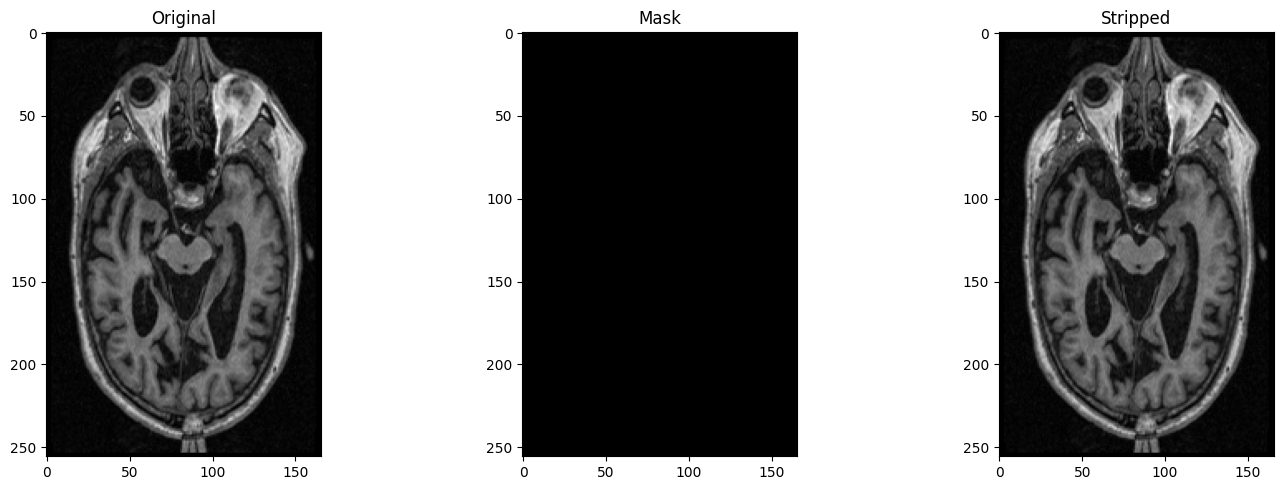

In [8]:
# Example usage
#if __name__ == "__main__":
stripper = BrainMRISkullStripper(verbose=True)
    
# Example input and output paths
input_file = "MRI-Input/Alzheimer-Desease.nii"  # Replace with your MRI file
output_file = "MRI-Output/skull_stripped_brain-02.nii"
    
if os.path.exists(input_file):
        stripped, mask = stripper.process_pipeline(input_file, output_file)
else:
        print(f"File not found: {input_file}")
        print("Creating sample data for demonstration...")
        
        # Create sample 3D brain data
        x, y, z = np.ogrid[-50:50, -50:50, -50:50]
        brain = np.sqrt(x**2 + y**2 + z**2) <= 30
        brain = brain.astype(np.float32)
        brain += np.random.normal(0, 0.1, brain.shape)
        
        # Add skull
        skull = np.sqrt(x**2 + y**2 + z**2) <= 40
        skull = skull & (~brain)
        brain[skull] = 0.5
        
        stripped, mask = stripper.skull_stripping(brain)
        stripper.visualize(brain, stripped, mask)

In [104]:
import numpy as np
import nibabel as nib
from skimage.filters import threshold_otsu
from skimage.morphology import binary_closing, remove_small_objects
import skimage.morphology
import skimage.morphology.binary

def skull_strip_mri(input_path, output_path=None, visualize=False):
    """
    Perform skull stripping on a brain MRI scan
    
    Args:
        input_path (str): Path to input MRI file (NIfTI format)
        output_path (str, optional): Path to save skull-stripped output
        visualize (bool): Whether to show before/after results (default False)
    
    Returns:
        tuple: (stripped_brain, brain_mask) as numpy arrays
    """
    # 1. Load MRI data
    img = nib.load(input_path)
    data = img.get_fdata()
    
    # 2. Normalize and threshold
    normalized = (data - np.min(data)) / (np.max(data) - np.min(data))
    mask = normalized > threshold_otsu(normalized)
    
    # 3. Clean up mask
    mask = binary_closing(mask)
    #mask = skimage.morphology.binary_fill_holes(mask)
    mask = remove_small_objects(mask, min_size=500)
    
    # 4. Apply mask
    stripped = data * mask
    
    # 5. Save result if output path provided
    if output_path:
        nib.save(nib.Nifti1Image(stripped, img.affine), output_path)
    
    # 6. Optional visualization
    if visualize:
        import matplotlib.pyplot as plt
        slice_idx = data.shape[0] // 2
        plt.figure(figsize=(12, 6))
        plt.subplot(121)
        plt.imshow(data[slice_idx], cmap='gray')
        plt.title('Original')
        plt.subplot(122)
        plt.imshow(stripped[slice_idx], cmap='gray')
        plt.title('Skull Stripped')
        plt.show()
    
    return stripped, mask

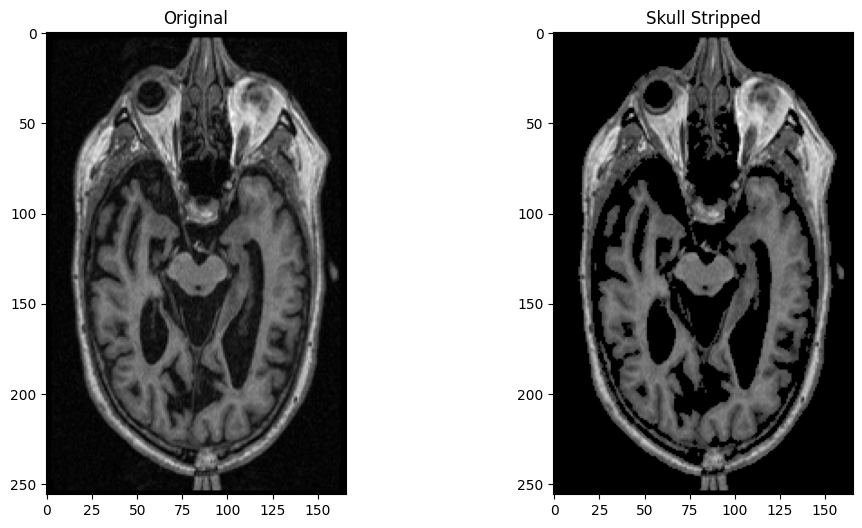

(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        ...,
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],


In [105]:
# Basic usage
stripped_brain, mask = skull_strip_mri('MRI-Input/Alzheimer-Desease.nii', 'MRI-Output/output_stripped.nii.gz')

# With visualization
skull_strip_mri('MRI-Input/Alzheimer-Desease.nii', visualize=True)

## SKULL STRIPPING

In [10]:
import SimpleITK as sitk
import nibabel as nib
import numpy as np
import os

def skull_strip_mri(input_path, output_path=None, visualize=False):
    """
    Robust skull stripping using SimpleITK
    
    Args:
        input_path (str): Path to input MRI (NIfTI, DICOM, etc.)
        output_path (str, optional): Output path for stripped image
        visualize (bool): Whether to show results (default False)
    
    Returns:
        tuple: (stripped_array, mask_array)
    """
    try:
        # 1. Load image with proper casting
        img = sitk.ReadImage(input_path)
        img = sitk.Cast(img, sitk.sitkFloat32)
        
        # 2. Otsu thresholding with correct parameters
        otsu = sitk.OtsuThresholdImageFilter()
        otsu.SetInsideValue(1)
        otsu.SetOutsideValue(0)
        mask = otsu.Execute(img)
        
        # 3. Post-processing
        mask = sitk.BinaryMorphologicalClosing(mask, [3,3,3])
        mask = sitk.BinaryFillhole(mask)
        mask = sitk.BinaryOpeningByReconstruction(mask, [3,3,3])
        
        # 4. Apply mask
        stripped = sitk.Mask(img, mask)
        
        # 5. Save result if output path provided
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            sitk.WriteImage(stripped, output_path)
        
        # 6. Convert to numpy arrays
        stripped_array = sitk.GetArrayFromImage(stripped)
        mask_array = sitk.GetArrayFromImage(mask)
        
        # 7. Optional visualization
        if visualize:
            import matplotlib.pyplot as plt
    
            # Get middle slice index
            slice_idx = stripped_array.shape[0] // 2
    
            # Create figure with 3 subplots
            plt.figure(figsize=(18, 6))
    
            # Original image
            plt.subplot(131)
            plt.imshow(sitk.GetArrayFromImage(img)[slice_idx], cmap='gray')
            plt.title('Original MRI')
            plt.axis('off')
    
            # Brain mask
            plt.subplot(132)
            plt.imshow(mask_array[slice_idx], cmap='gray')
            plt.title('Brain Mask')
            plt.axis('off')
    
            # Skull-stripped result
            plt.subplot(133)
            plt.imshow(stripped_array[slice_idx], cmap='gray')
            plt.title('Skull-Stripped Result')
            plt.axis('off')
    
            plt.tight_layout()
            plt.show()
            return stripped_array, mask_array
    
    except Exception as e:
        print(f"Error processing {input_path}: {str(e)}")
        return None, None

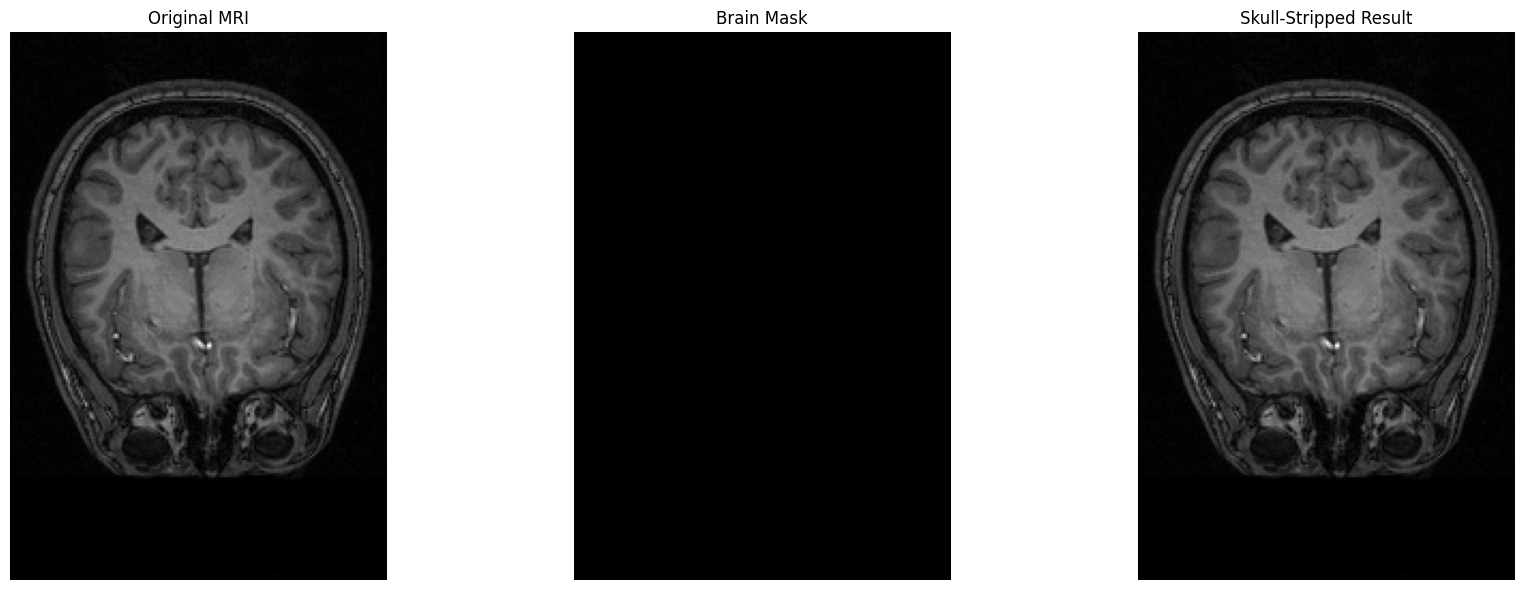

Skull stripping completed successfully!


In [11]:
# Basic usage with error handling
input_path = "MRI-Input/Alzheimer-Desease-02.nii"
output_path = "MRI-Output/stripped-02.nii.gz"

stripped, mask = skull_strip_mri(input_path, output_path, visualize=True)

if stripped is not None:
    print("Skull stripping completed successfully!")
else:
    print("Skull stripping failed - check error message")

## INTENSITY NORMALIZATION

In [12]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os

def normalize_mri_intensity(input_path, output_path=None, 
                          lower_percentile=1, upper_percentile=99,
                          visualize=True):
    """
    Normalize MRI intensity with visualization
    
    Args:
        input_path: Input MRI file path
        output_path: Output file path (optional)
        lower_percentile: Lower intensity cutoff (1-100)
        upper_percentile: Upper intensity cutoff (1-100)
        visualize: Show before/after plots (default True)
    
    Returns:
        Normalized SimpleITK image
    """
    try:
        # 1. Load image
        img = sitk.ReadImage(input_path)
        img_array = sitk.GetArrayFromImage(img)
        
        # 2. Calculate percentiles
        lower = np.percentile(img_array, lower_percentile)
        upper = np.percentile(img_array, upper_percentile)
        
        # 3. Normalize intensities
        normalized = sitk.IntensityWindowing(
            img,
            windowMinimum=lower,
            windowMaximum=upper,
            outputMinimum=0.0,
            outputMaximum=1.0
        )
        norm_array = sitk.GetArrayFromImage(normalized)
        
        # 4. Save result
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            sitk.WriteImage(normalized, output_path)
        
        # 5. Visualization
        if visualize:
            slice_idx = img_array.shape[0] // 2  # Middle slice
            
            plt.figure(figsize=(15, 5))
            
            # Original image
            plt.subplot(131)
            plt.imshow(img_array[slice_idx], cmap='gray', vmin=lower, vmax=upper)
            plt.title(f'Original\nRange: [{lower:.1f}, {upper:.1f}]')
            plt.colorbar()
            
            # Normalized image
            plt.subplot(132)
            plt.imshow(norm_array[slice_idx], cmap='gray', vmin=0, vmax=1)
            plt.title('Normalized\nRange: [0.0, 1.0]')
            plt.colorbar()
            
            # Histogram comparison
            plt.subplot(133)
            plt.hist(img_array.flatten(), bins=100, alpha=0.5, label='Original')
            plt.hist(norm_array.flatten(), bins=100, alpha=0.5, label='Normalized')
            plt.legend()
            plt.title('Intensity Distribution')
            
            plt.tight_layout()
            plt.show()
        
        return normalized
        
    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None

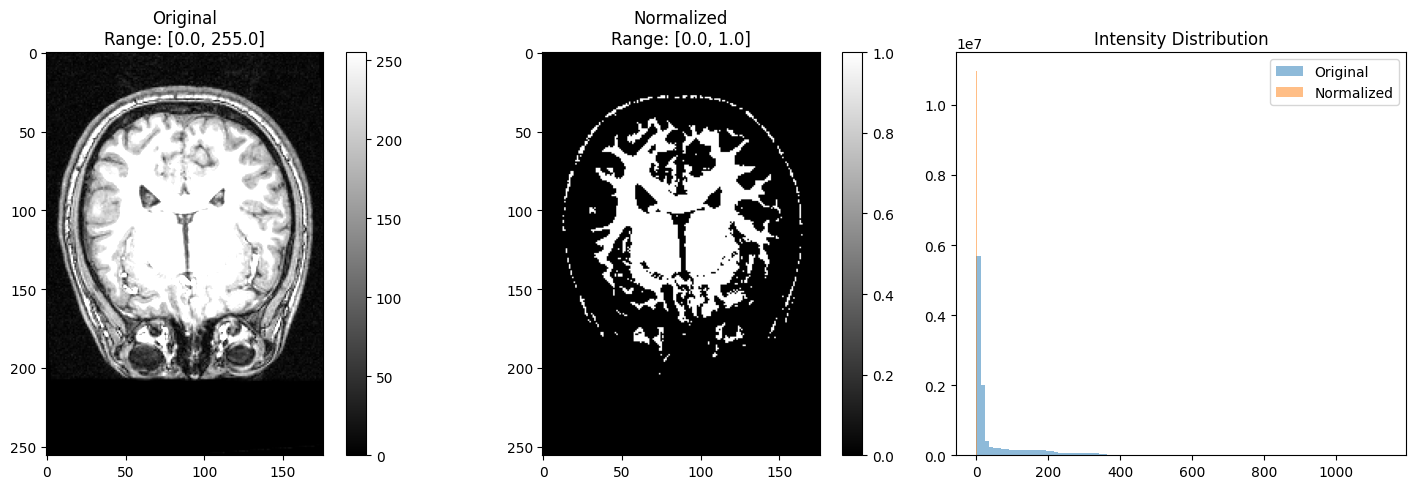

In [16]:
input_path = "MRI-Input/Alzheimer-Desease-02.nii"
output_path = "MRI-Output/Normalised-02.nii.gz"

# Normalize with default percentiles (1-99)
#normalized_img = normalize_mri_intensity("input.nii", "output.nii.gz")

# Custom percentile range
normalized_img = normalize_mri_intensity(input_path, 
                                       output_path,
                                       lower_percentile=5,
                                       upper_percentile=95
                                        )

## TISSUE SEGMENTATION

In [17]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans

def segment_brain_tissues(input_path, output_path=None, visualize=True):
    """
    Perform brain tissue segmentation using K-means clustering
    
    Args:
        input_path: Path to input MRI (NIfTI/DICOM)
        output_path: Directory to save segments (optional)
        visualize: Show results (default True)
    
    Returns:
        Dictionary with keys: 'gray_matter', 'white_matter', 'csf', 'labeled'
        or None if failed
    """
    try:
        # 1. Load and verify image
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Input file not found: {input_path}")
        
        img = sitk.ReadImage(input_path)
        if img.GetSize() == (0,0,0):
            raise ValueError("Empty image loaded")
        
        # 2. Preprocessing
        img = sitk.Cast(img, sitk.sitkFloat32)
        img_array = sitk.GetArrayFromImage(img)
        
        # 3. Intensity normalization (0-1 range)
        img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array))
        
        # 4. K-means segmentation using scikit-learn
        kmeans = KMeans(n_clusters=3, random_state=0)
        flat_img = img_array.reshape(-1, 1)
        labels = kmeans.fit_predict(flat_img)
        labeled_array = labels.reshape(img_array.shape)
        
        # Sort clusters by intensity (CSF=0, GM=1, WM=2)
        cluster_means = [np.mean(img_array[labeled_array == i]) for i in range(3)]
        sorted_clusters = np.argsort(cluster_means)
        
        # 5. Create tissue masks
        csf_mask = (labeled_array == sorted_clusters[0]).astype(np.float32)
        gm_mask = (labeled_array == sorted_clusters[1]).astype(np.float32)
        wm_mask = (labeled_array == sorted_clusters[2]).astype(np.float32)
        
        # Convert back to SimpleITK images
        csf_mask = sitk.GetImageFromArray(csf_mask)
        gm_mask = sitk.GetImageFromArray(gm_mask)
        wm_mask = sitk.GetImageFromArray(wm_mask)
        labeled = sitk.GetImageFromArray(labeled_array.astype(np.float32))
        
        # Copy metadata from original image
        for mask in [csf_mask, gm_mask, wm_mask, labeled]:
            mask.CopyInformation(img)
        
        # 6. Prepare results
        results = {
            'gray_matter': gm_mask,
            'white_matter': wm_mask,
            'csf': csf_mask,
            'labeled': labeled
        }
        
        # 7. Save outputs if requested
        if output_path:
            os.makedirs(output_path, exist_ok=True)
            sitk.WriteImage(gm_mask, os.path.join(output_path, "gm.nii.gz"))
            sitk.WriteImage(wm_mask, os.path.join(output_path, "wm.nii.gz"))
            sitk.WriteImage(csf_mask, os.path.join(output_path, "csf.nii.gz"))
            sitk.WriteImage(labeled, os.path.join(output_path, "all_tissues.nii.gz"))
        
        # 8. Visualization
        if visualize:
            slice_idx = img_array.shape[0] // 2
            
            plt.figure(figsize=(15,5))
            
            plt.subplot(131)
            plt.imshow(img_array[slice_idx], cmap='gray')
            plt.title("Original MRI")
            
            plt.subplot(132)
            plt.imshow(labeled_array[slice_idx])
            plt.title("Tissue Classes")
            
            plt.subplot(133)
            plt.hist(img_array.flatten(), bins=100, alpha=0.5, label='Original')
            for i, name in zip(range(3), ['CSF', 'GM', 'WM']):
                plt.hist(img_array[labeled_array == i].flatten(), 
                        bins=20, alpha=0.5, label=name)
            plt.legend()
            plt.title("Tissue Intensity Distribution")
            
            plt.tight_layout()
            plt.show()
            
        return results
        
    except Exception as e:
        print(f"Segmentation Error: {str(e)}")
        return None

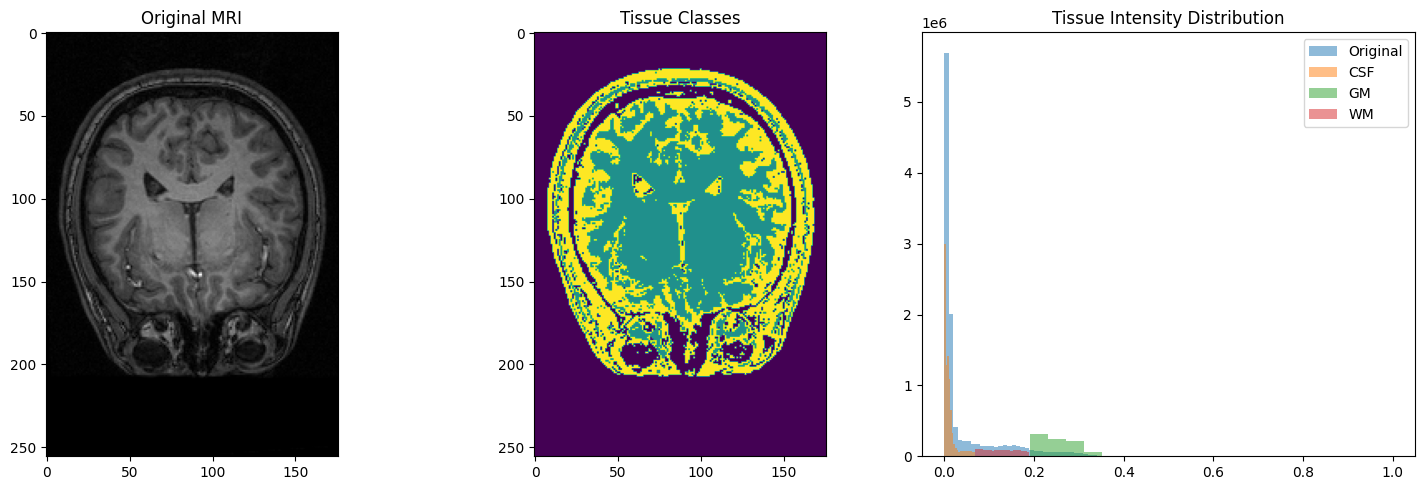

In [18]:
# Example usage with scikit-learn
results = segment_brain_tissues(
    input_path="MRI-Input/Alzheimer-Desease-02.nii",
    output_path="MRI-Output/",
    visualize=True
)

if results is not None:
    # Access results safely
    gm = sitk.GetArrayFromImage(results['gray_matter'])
    wm = sitk.GetArrayFromImage(results['white_matter'])
    csf = sitk.GetArrayFromImage(results['csf'])

## MNI 152 TEMPLATE REGISTRATION

In [20]:
import SimpleITK as sitk
import os
import urllib.request
import tempfile
import zipfile
import shutil

def register_to_mni152(input_path, output_path=None, verbose=False):
    """
    Robust MRI registration to MNI152 template with automatic template download
    
    Args:
        input_path: Path to input MRI (NIfTI format)
        output_path: Path to save registered image (optional)
        verbose: Print progress messages (default False)
    
    Returns:
        sitk.Image: Registered image in MNI152 space
    """
    try:
        # 1. Verify input exists
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Input file not found: {input_path}")

        # 2. Get or download MNI152 template
        template_url = "https://www.bic.mni.mcgill.ca/~vfonov/icbm/2009/mni_icbm152_nlin_sym_09a_nifti.zip"
        
        # Try SimpleITK's built-in template first
        try:
            fixed_image = sitk.ReadImage(os.path.join(sitk.GetDataPath(), "MNI152_T1_1mm.nii.gz"))
            if verbose: print("Using built-in MNI152 template")
        except:
            if verbose: print("Downloading MNI152 template...")
            
            # Create temporary directory
            temp_dir = tempfile.mkdtemp()
            try:
                # Download template
                zip_path = os.path.join(temp_dir, "mni_template.zip")
                urllib.request.urlretrieve(template_url, zip_path)
                
                # Extract the correct file from zip
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    # Find the T1 file in the archive
                    for file in zip_ref.namelist():
                        if file.endswith("mni_icbm152_t1_tal_nlin_sym_09a.nii"):
                            # Extract to temporary directory
                            zip_ref.extract(file, temp_dir)
                            template_path = os.path.join(temp_dir, file)
                            break
                    else:
                        raise FileNotFoundError("Could not find T1 file in template archive")
                
                fixed_image = sitk.ReadImage(template_path)
                if verbose: print("Template downloaded and extracted successfully")
            finally:
                # Clean up temporary directory
                shutil.rmtree(temp_dir, ignore_errors=True)

        # 3. Load moving image
        if verbose: print("Loading input image...")
        moving_image = sitk.ReadImage(input_path)
        moving_image = sitk.Cast(moving_image, sitk.sitkFloat32)

        # 4. Initial alignment
        if verbose: print("Initial alignment...")
        initial_transform = sitk.CenteredTransformInitializer(
            fixed_image, 
            moving_image, 
            sitk.Euler3DTransform(), 
            sitk.CenteredTransformInitializerFilter.GEOMETRY
        )

        # 5. Configure registration
        registration_method = sitk.ImageRegistrationMethod()
        registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
        registration_method.SetMetricSamplingStrategy(registration_method.RANDOM)
        registration_method.SetMetricSamplingPercentage(0.1)
        registration_method.SetInterpolator(sitk.sitkLinear)
        registration_method.SetOptimizerAsGradientDescent(
            learningRate=1.0, 
            numberOfIterations=100,
            convergenceMinimumValue=1e-6,
            convergenceWindowSize=10
        )
        registration_method.SetOptimizerScalesFromPhysicalShift()
        registration_method.SetInitialTransform(initial_transform, inPlace=False)

        # 6. Execute registration
        if verbose: print("Running registration...")
        final_transform = registration_method.Execute(fixed_image, moving_image)

        # 7. Apply transformation
        if verbose: print("Applying transformation...")
        registered_image = sitk.Resample(
            moving_image,
            fixed_image,
            final_transform,
            sitk.sitkLinear,
            0.0,
            moving_image.GetPixelID()
        )

        # 8. Save result
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            sitk.WriteImage(registered_image, output_path)
            if verbose: print(f"Saved registered image to: {output_path}")

        return registered_image

    except Exception as e:
        print(f"Registration failed: {str(e)}")
        return None

Template downloaded and extracted successfully
Loading input image...
Initial alignment...
Running registration...
Applying transformation...
Saved registered image to: MRI-Output/registered_scan.nii.gz


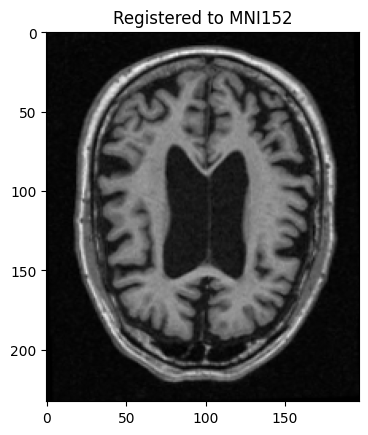

In [21]:
# Register with automatic template handling
registered_img = register_to_mni152(
    input_path="MRI-Input/Alzheimer-Desease.nii",
    output_path="MRI-Output/registered_scan.nii.gz",
    verbose=True
)

if registered_img is not None:
    # Visualize results
    import matplotlib.pyplot as plt
    plt.imshow(sitk.GetArrayFromImage(registered_img)[100], cmap='gray')
    plt.title("Registered to MNI152")
    plt.show()
else:
    print("Registration failed - check error message")